In [12]:
# Tutorial for recreating plots like Figures 4 and 6 in Hasler et al.
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.append('..')
import deconfuser.sample_planets as sample_planets

##### Read in the files that contain the true orbital parameters and the parameters of the ranked options
- true_orbits_for_plotting.csv
- ranked_confused_options_for_plotting.csv

In [ ]:
# Read in the true orbits and orbit fits
true_params_file = "system_files/true_orbits_for_plotting.csv"
ranked_file = "system_files/ranked_confused_options_for_plotting.csv"

df_true = pd.read_csv(true_params_file)
df_ranked = pd.read_csv(ranked_file)

In [14]:
def plot_system_options(df_true, df_ranked, n_system, incl_group, 
                        markers=['o', 's', 'v'], colors=['#72D7E1', '#912F56', '#E99D98'],
                        mu=4*np.pi**2, xlim=None, ylim=None):
    """
    Plot the true system detections with the orbit options returned by the astrometric deconfuser.

    Parameters
    ----------
    df_true : pandas.DataFrame
        DataFrame containing the true system parameters and detections.
    df_ranked : pandas.DataFrame
        DataFrame containing the ranked orbit options for each system and inclination group.
    n_system : int
        The system number to plot (1-10).
    incl_group : str
        The inclination group to plot ('low', 'med', or 'high').
    """

    # Check if incl_group is in the dataframe
    if incl_group not in df_true['incl_group'].unique():
        print(f"Error: {incl_group} is not a valid inclination group. incl_group should be one of: {df_true['incl_group'].unique()}")
        return
    
    # Filter the dataframes for the given system number and inclination group
    true_system_df = df_true[(df_true['system'] == n_system) & (df_true['incl_group'] == incl_group)]
    confused_systems_df = df_ranked[(df_ranked['system'] == n_system) & (df_ranked['incl_group'] == incl_group)]

    # Get unique partitions (options) 
    confused_partitions = confused_systems_df['partition'].unique()

    # Iterate over top partitions
    n_partition = 0
    fig, ax = plt.subplots(1, len(confused_partitions), figsize=(8*len(confused_partitions), 4))

    for partition in confused_partitions:
        partition_df = confused_systems_df[(confused_systems_df['partition'] == partition)] # df of only the current partition
        L_option = np.prod(partition_df['L_orbit'].values)

        # Plot system detections
        for index, row in true_system_df.iterrows():
            xyzs = eval(row['xyzs']) 
            for detection in range(len(xyzs)):
                ax[n_partition].scatter(xyzs[detection][0], xyzs[detection][1], marker=markers[detection], s=100, c='k')

        # Plot each orbit option
        j = 0
        for index, row in partition_df.iterrows():
            # Calculate orbit track
            xs_track, ys_track, zs_track = sample_planets.get_observations(float(row['top_a']), float(row['top_e']), float(row['top_i']), 
                                                                            float(row['top_o']), float(row['top_O']), float(row['top_M0']),
                                                                            2*np.pi*np.sqrt(float(row['top_a'])**3/mu)*np.arange(0,1.1,0.01), mu)
            incl = np.rad2deg(row['top_i'])
            ax[n_partition].plot(xs_track[0], ys_track[0], lw=3, color=colors[j], alpha=0.75,
                       label=f"$a_{j+1}$={row['top_a']:.2f} AU\n$e_{j+1}$={row['top_e']:.2f}\n$i_{j+1}$={incl:.2f}°")
            j += 1

        ax[n_partition].scatter(0, 0, marker='*', s=150, c='gold')
        ax[n_partition].legend(bbox_to_anchor=(1.05,-0.15), ncols=3)
        ax[n_partition].set_title(f"System {n_system}, {incl_group} Inc.\nPossible Orbits {n_partition+1}")
        ax[n_partition].set_xlabel('x (AU)')
        ax[n_partition].set_ylabel('y (AU)')
        ax[n_partition].set_ylim(ylim)
        ax[n_partition].set_xlim(xlim)

        n_partition += 1

    plt.show()

def compare_topranked_true(df_true, df_ranked, n_system, incl_groups=['low', 'med', 'high'], markers=['o', 's', 'v'], colors=['#72D7E1', '#912F56', '#E99D98'],
                        mu=4*np.pi**2, xlim=None, ylim=None):
    """
    Compare the top-ranked orbit option from the photometry ranking scheme to the true orbit.

    Parameters
    ----------
    df_true : pandas.DataFrame
        DataFrame containing the true system parameters and detections.
    df_ranked : pandas.DataFrame
        DataFrame containing the ranked orbit options for each system and inclination group.
    n_system : int
        The system number to plot (1-10).
    mu : float, optional
       Solar gravitational parameter, by default 4*np.pi**2 (Sun)
    xlim : tuple, optional
        The x-axis limits for the plot, by default None
    ylim : tuple, optional
        The y-axis limits for the plot, by default None
    """
    jj = 0
    fig, ax = plt.subplots(1, 3, figsize=(20, 6))

    for incl_group in incl_groups:
        # Filter the dataframes for the given system number and inclination group
        true_system_df = df_true[(df_true['system'] == n_system) & (df_true['incl_group'] == incl_group)]
        top_ranked_df = df_ranked[(df_ranked['system'] == n_system) & (df_ranked['incl_group'] == incl_group) & (df_ranked['ranking'] == 0)] # only the top ranked option

        ii = 0 # for labeling detections and options
        plt.figure(figsize=(8,6))
        for index, row in true_system_df.iterrows():
            xyzs = eval(row['xyzs'])
            xs_orbit, ys_orbit, zs_orbit = sample_planets.get_observations(float(row['a']), float(row['e']), float(row['i']), 
                                                                        float(row['o']), float(row['O']), float(row['M0']),
                                                                        2*np.pi*np.sqrt(float(row['a'])**3/mu)*np.arange(0,1,0.01),
                                                                        mu)
            for detection in range(len(xyzs)):
                ax[jj].scatter(xyzs[detection][0], xyzs[detection][1], marker=markers[detection], s=100, c='k') # Plot detections
            ax[jj].plot(xs_orbit[0], ys_orbit[0], lw=2, color='k', alpha=0.7, label=f"True Orbit" if ii==0 else "") # plot orbit track

            ii += 1

        cs = 0
        for index, row in top_ranked_df.iterrows():
            xs_orbit, ys_orbit, zs_orbit = sample_planets.get_observations(float(row['top_a']), float(row['top_e']),
                                                                            float(row['top_i']), float(row['top_o']),
                                                                            float(row['top_O']), float(row['top_M0']),
                                                                            2*np.pi*np.sqrt(float(row['top_a'])**3/mu)*np.arange(0,1,0.01), 
                                                                            mu)
            
            ax[jj].plot(xs_orbit[0], ys_orbit[0], lw=3, alpha=0.9, color=colors[cs], linestyle='dashed')
            cs += 1
            
        ax[jj].scatter(0, 0, marker='*', s=150, c='gold')
        ax[jj].set_xlabel('x (AU)')
        ax[jj].set_ylabel('y (AU)')
        ax[jj].set_xlim(xlim)
        ax[jj].set_ylim(ylim)
        ax[jj].set_title(f"System {n_system}\n{incl_group} incl.")
        
        jj += 1

    plt.show()

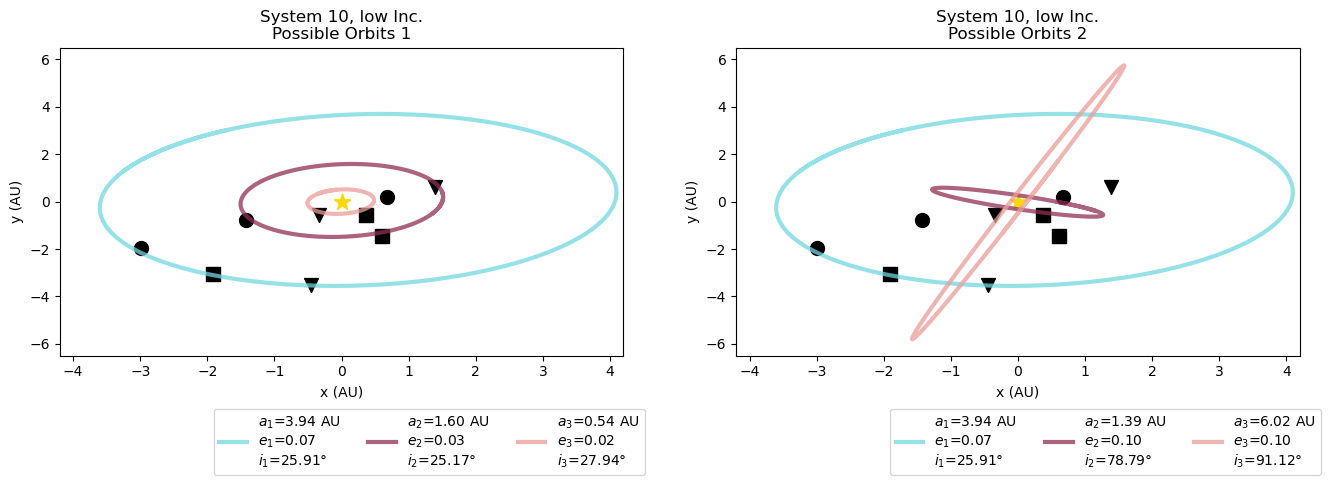

In [ ]:
# Low inclination
plot_system_options(df_true, df_ranked, n_system=10, incl_group="low", xlim=[-4.2,4.2], ylim=[-6.5,6.5])

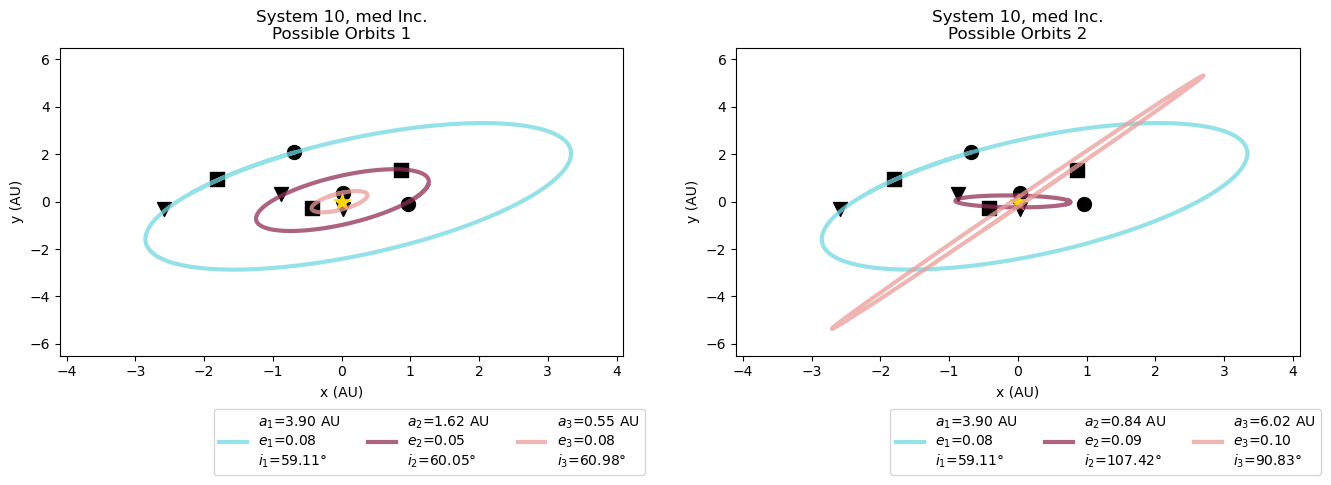

In [ ]:
# Medium inclination
plot_system_options(df_true, df_ranked, n_system=10, incl_group="med", xlim=[-4.1,4.1], ylim=[-6.5,6.5])

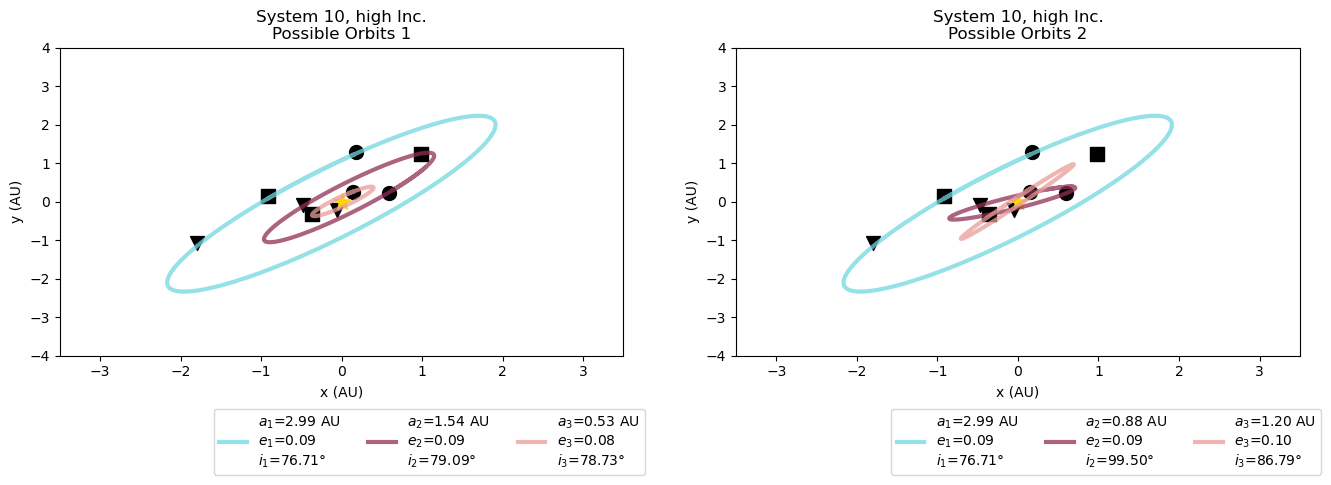

In [ ]:
# High inclination
plot_system_options(df_true, df_ranked, n_system=10, incl_group="high", xlim=[-3.5,3.5], ylim=[-4,4])

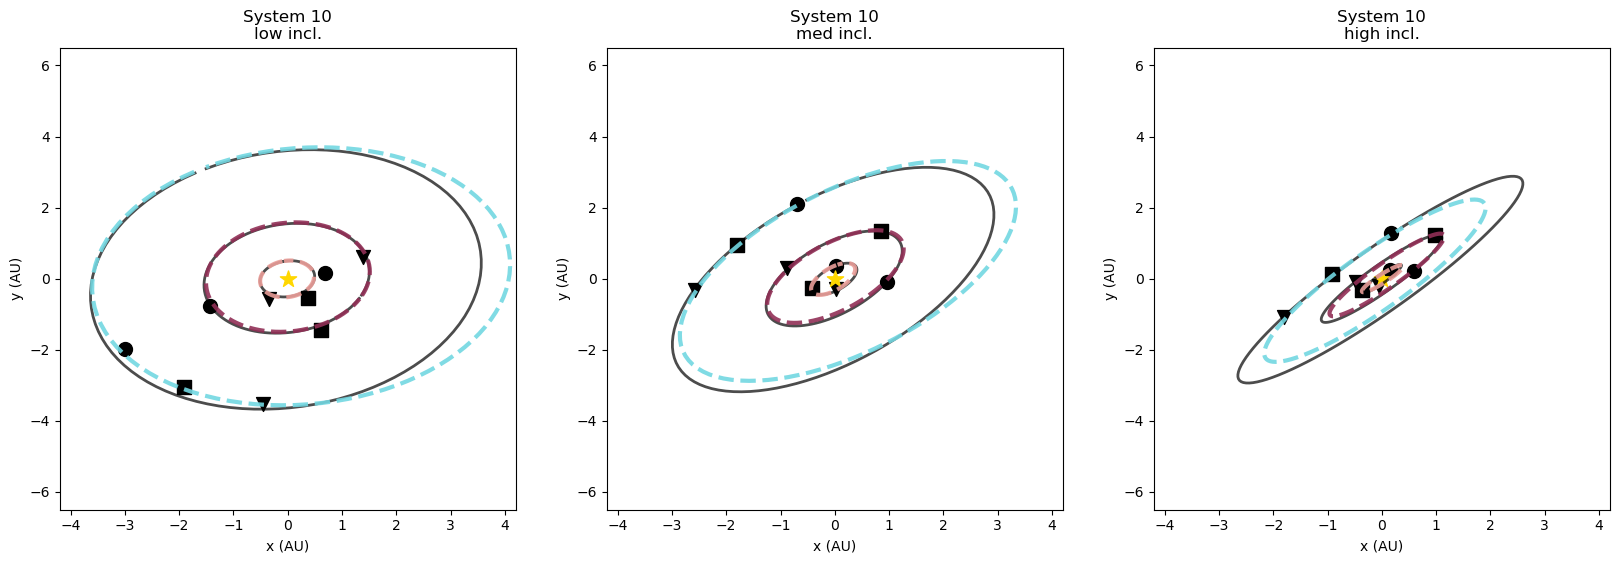

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

In [ ]:
# compare the top ranked orbit option from photometry to the true orbits
compare_topranked_true(df_true, df_ranked, n_system=10, xlim=[-4.2,4.2], ylim=[-6.5,6.5])